Fit a simple causal model based only on price for a single tier. Based on the results (and on the visual data inspection as well), it seems like price alone is not enough to predict if a lone is being accepted or not. Indeed, the model being fitted here is essentially predicting a constant probability of acceptance equal to the rate of accepted loans in the df. The model also shows some convergence issues

In [16]:
import pymc as pm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, auc, roc_curve

In [17]:
df = pd.read_excel("data/data.xlsx")
df["DeltaCompetition"] = df["Rate"] - df["Competition rate"]
#Start with only one Tier
df = df[df["Tier"]==2]
print(f"{df['Outcome'].mean()*100:.2f} % of the loans in the data set have been accepted")
#Use the offered rate as only explanatory var
prices_train, prices_test, accepted_train, accepted_test = train_test_split(df["Rate"].values, df["Outcome"].values,
                                                                            train_size=0.8, shuffle=True, random_state=1)

#Use the delta between the competitor price and the offered rate as only explanatory var
#prices_train, prices_test, accepted_train, accepted_test = train_test_split(df["DeltaCompetition"].values, df["Outcome"].values,
#                                                                            train_size=0.8, shuffle=True, random_state=1)
df.head()

20.40 % of the loans in the data set have been accepted


,N,Approval Date,Tier,FICO,Term,Amount,Loan Type,Previous Rate,Competition rate,Cost of Funds,Partner,Rate,Outcome,DeltaCompetition
0,1,2005-04-17,2,702,48,26500.00,R,0.0399,0.0499,0.011,2,0.0659,0,0.0160
1,2,2005-04-17,2,719,72,34999.99,N,0.0000,0.0479,0.011,2,0.0599,0,0.0120
7,8,2005-04-17,2,726,60,21596.00,R,0.0599,0.0499,0.011,2,0.0525,0,0.0026
11,12,2005-04-17,2,726,60,25000.00,N,0.0000,0.0399,0.011,3,0.0579,0,0.0180
14,15,2005-04-17,2,728,48,25854.00,U,0.0000,0.0455,0.011,1,0.0589,0,0.0134


Text(0.5, 1.0, 'Observed Acceptance vs offered rate')

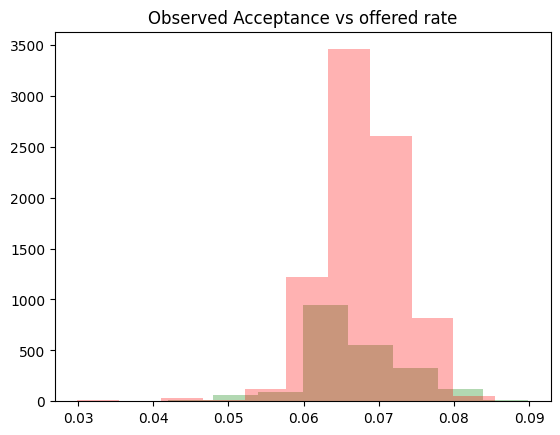

In [18]:
# Show data
plt.hist(df[df["Outcome"]==1]["Rate"], alpha=0.3, color="green")
plt.hist(df[df["Outcome"]==0]["Rate"], alpha=0.3, color="red")
plt.title("Observed Acceptance vs offered rate")

In [19]:
#Start considering price as only factor
base_model = pm.Model()

with base_model:
    offered_rates = pm.Data("offered_rate", prices_train)
    y = pm.Data("y", accepted_train)

    # Priors for coefficients
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=10)
    
    #force it to be negative
    #beta_1 = -1*pm.LogNormal('beta_1', mu=0, sigma=1)
    #With error term slightly better energy plot but confidence interval get very large
    #epsilon = pm.Normal("epsilon", mu=0, sigma=0.01)


    # Linear model
    logit_p = beta_0 + beta_1*offered_rates #+ epsilon

    # Likelihood
    p = pm.Deterministic('acceptance_p', pm.math.sigmoid(logit_p))
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y)

In [20]:
#Check the prior distribution
with base_model:
    prior_data = pm.sample_prior_predictive(draws=50, random_seed=123)


Sampling: [beta_0, beta_1, y_obs]


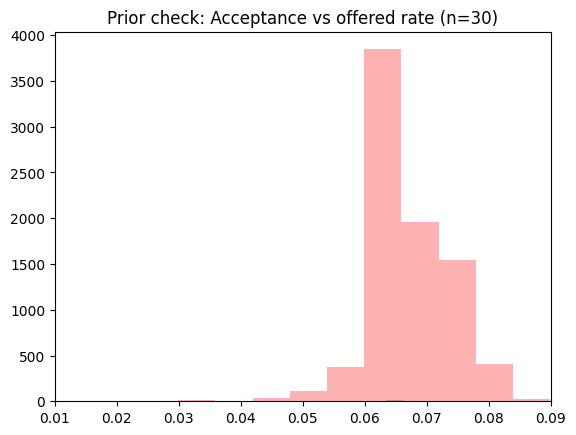

In [21]:
random_idx = np.random.randint(50)
df_prior = pd.DataFrame({"Rate":prices_train, "Outcome": prior_data["prior_predictive"]["y_obs"][0,random_idx,:]})
plt.hist(df_prior[df_prior["Outcome"]==1]["Rate"], alpha=0.3, color="green")
plt.hist(df_prior[df_prior["Outcome"]==0]["Rate"], alpha=0.3, color="red")
plt.xticks([i*0.01 for i in range(10)])
plt.xlim(0.01,0.09)
plt.title(f"Prior check: Acceptance vs offered rate (n={random_idx})")
plt.show()

In [22]:
#Faster sampler -- need to install jax and blackjax. Otherwise use slow sampler
trace = pm.sample(draws=5000, tune=1000, nuts_sampler="blackjax", cores=4, model=base_model)

#Slow Sampler
#with base_model:
#    trace = pm.sample(2000)

Running window adaptation


<Axes: >

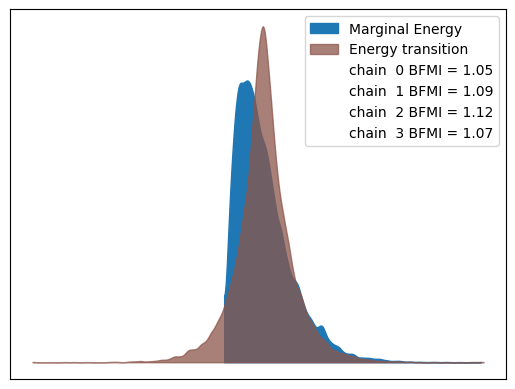

In [23]:
#Check convergence - energy plot
pm.plot_energy(trace)

array([[<Axes: title={'center': 'beta_0'}>,
        <Axes: title={'center': 'beta_0'}>],
       [<Axes: title={'center': 'beta_1'}>,
        <Axes: title={'center': 'beta_1'}>]], dtype=object)

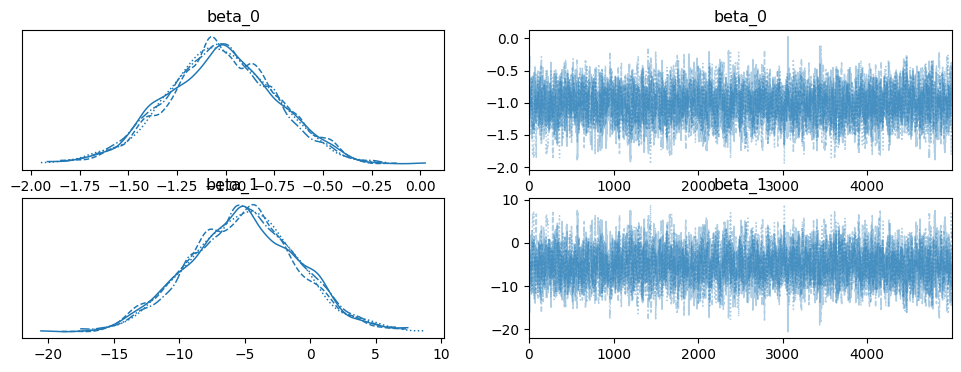

In [24]:
#check convergence - plot trace
az.plot_trace(trace, var_names=["beta_0", "beta_1"])

In [25]:
az.summary(trace, var_names=["beta_0", "beta_1"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-1.027,0.281,-1.538,-0.479,0.006,0.004,2409.0,2893.0,1.0
beta_1,-5.066,4.156,-13.251,2.394,0.084,0.060,2420.0,2963.0,1.0


array([<Axes: title={'center': 'beta_0'}>,
       <Axes: title={'center': 'beta_1'}>], dtype=object)

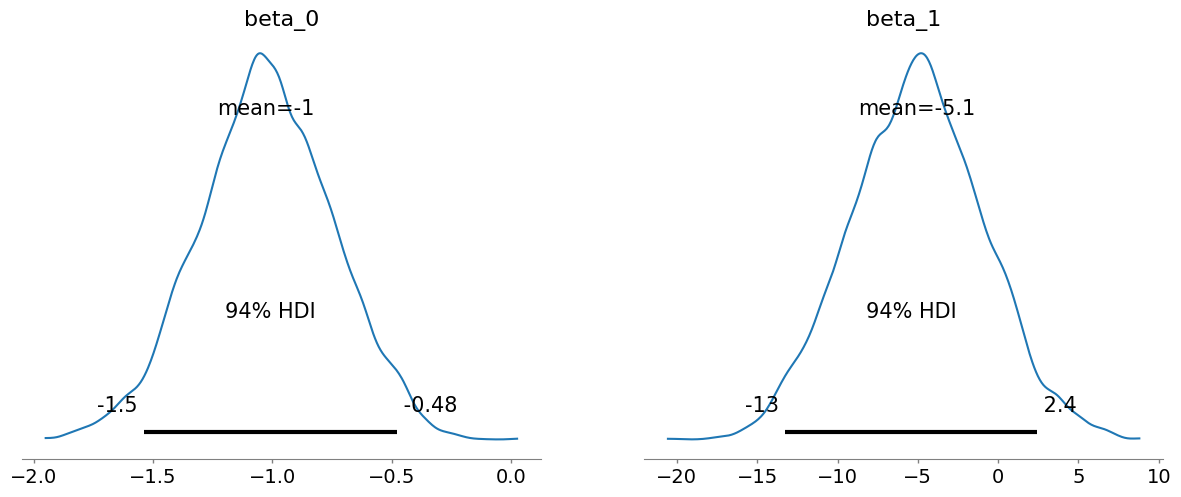

In [26]:
az.plot_posterior(trace, var_names=["beta_0", "beta_1"])

Text(0.5, 1.0, 'Estimated price acceptance curve')

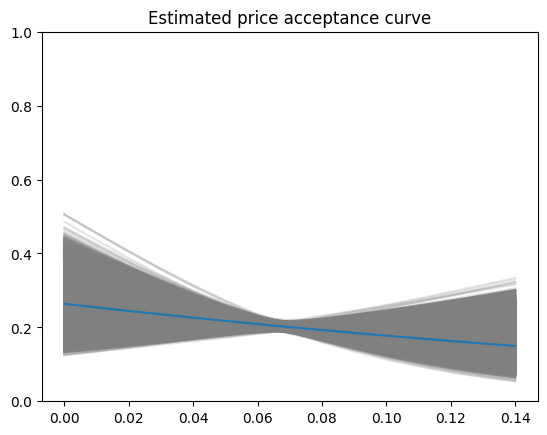

In [27]:
# based on the posterior samples we can estimate the resposne of the consumer to price changes
beta_0_posterior = np.asarray(trace["posterior"]["beta_0"]).ravel()
beta_1_posterior = np.asarray(trace["posterior"]["beta_1"]).ravel()
beta_0_mean = np.mean(beta_0_posterior)
beta_1_mean = np.mean(beta_1_posterior)

price_range = np.asarray([0.01 * i for i in range(15)])
acceptance_probability_mean = 1/(1+np.exp(-(beta_0_mean + beta_1_mean*price_range)))

for i,b_0 in enumerate(beta_0_posterior):
    b_1 = beta_1_posterior[i]
    acceptance_probability = 1/(1+np.exp(-(b_0 + b_1*price_range)))
    plt.plot(price_range, acceptance_probability, color="gray", alpha=0.2)

plt.plot(price_range, acceptance_probability_mean)
plt.ylim([0,1])
plt.title("Estimated price acceptance curve")

In [28]:
#Test oos predictions
with base_model:
    pm.set_data({"offered_rate":prices_test, "y": accepted_test})
    extended_trace = pm.sample_posterior_predictive(trace, progressbar=True, predictions=True)

Sampling: [y_obs]


/home/eguzzi/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

(array([ 41., 192., 617., 764., 389.,  67.,  16.,   1.,   2.,   3.]),
 array([0.18585 , 0.191255, 0.19666 , 0.202065, 0.20747 , 0.212875,
        0.21828 , 0.223685, 0.22909 , 0.234495, 0.2399  ]),
 <BarContainer object of 10 artists>)

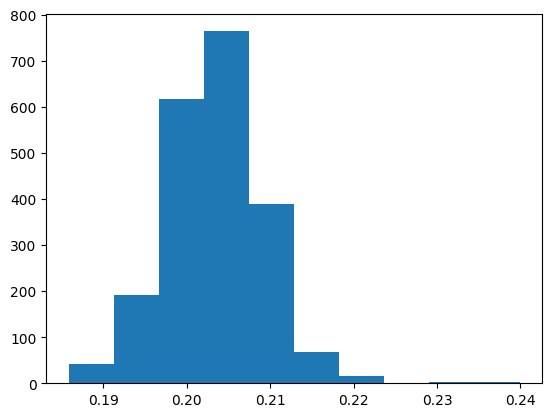

In [29]:
predicted_probabilities = extended_trace["predictions"]["y_obs"].mean(dim=["chain", "draw"])
plt.hist(predicted_probabilities) #essentially predicting constant 20% prob

[Text(0.5, 1.0, 'ROC')]

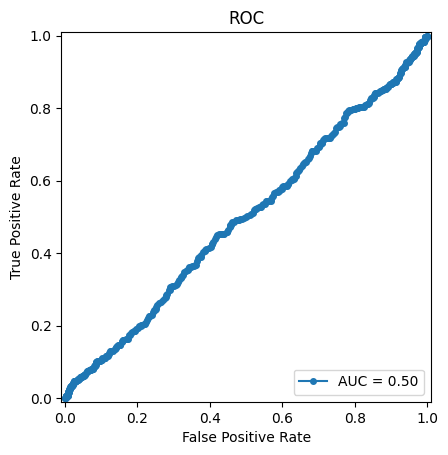

In [30]:
fpr, tpr, thresholds = roc_curve(y_true=accepted_test, y_score=predicted_probabilities, pos_label=1, drop_intermediate=False)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display = roc_display.plot(ax=ax, marker="o", markersize=4)
ax.set(title="ROC")
#same performance as random classifie

The book claims that only using price they were able to reach AUC of 60. Consider a simple baseline model predicting for each loan the acceptance probability as the average acceptance probability in the loan's tier. 

In [32]:
df_baseline = pd.read_excel("data/data.xlsx")

,AcceptanceRate
Tier,
1,0.047547
2,0.067271
3,0.078328
4,0.102451


   Tier  AcceptanceRate
0     1        0.346429
1     2        0.204015
2     3        0.163920
3     4        0.189316


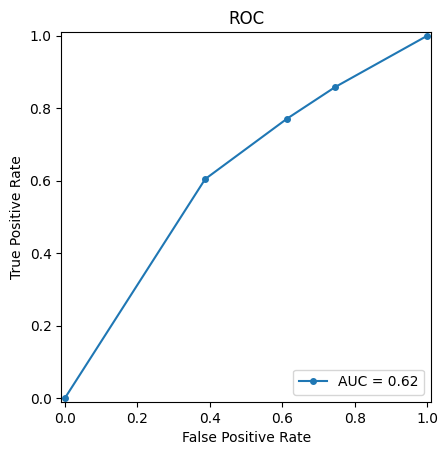

In [49]:
acceptance_rate_by_tier = df_baseline.groupby(["Tier"], as_index=False).agg(AcceptanceRate = ("Outcome", "mean"))
tier_train, tier_test, accepted_train, accepted_test = train_test_split(df_baseline["Tier"].values, df_baseline["Outcome"].values,
                                                                            train_size=0.8, shuffle=True, random_state=1)

prediction_baseline = [acceptance_rate_by_tier[acceptance_rate_by_tier["Tier"] == t]["AcceptanceRate"].values[0] for t in tier_test]

fpr, tpr, thresholds = roc_curve(y_true=accepted_test, y_score=prediction_baseline, pos_label=1, drop_intermediate=False)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots()
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display = roc_display.plot(ax=ax, marker="o", markersize=4)
ax.set(title="ROC")
print(acceptance_rate_by_tier)
